# Notebook 03 — Exploratory Data Analysis
**Project:** Credit Risk & Loan Default Analysis  
**Objective:** Uncover trends, distributions, and relationships in the cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/processed/loans_cleaned.csv', low_memory=False)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
print(f'Loaded: {df.shape}')

Loaded: (1348099, 32)


## 1. KPI Summary

In [2]:
print('=== Portfolio KPIs ===')
print(f"Total Loans:          {len(df):,}")
print(f"Total Loan Volume:    ${df['loan_amnt'].sum():,.0f}")
print(f"Overall Default Rate: {df['default_flag'].mean():.2%}")
print(f"Avg Loan Amount:      ${df['loan_amnt'].mean():,.0f}")
print(f"Avg Interest Rate:    {df['int_rate'].mean():.2f}%")
print(f"Avg DTI:              {df['dti'].mean():.2f}")
print(f"Avg FICO Score:       {df['fico_avg'].mean():.0f}")

=== Portfolio KPIs ===
Total Loans:          1,348,099
Total Loan Volume:    $19,424,757,025
Overall Default Rate: 19.98%
Avg Loan Amount:      $14,409
Avg Interest Rate:    13.24%
Avg DTI:              18.12
Avg FICO Score:       698


## 2. Trend Analysis — Default Rate Over Time

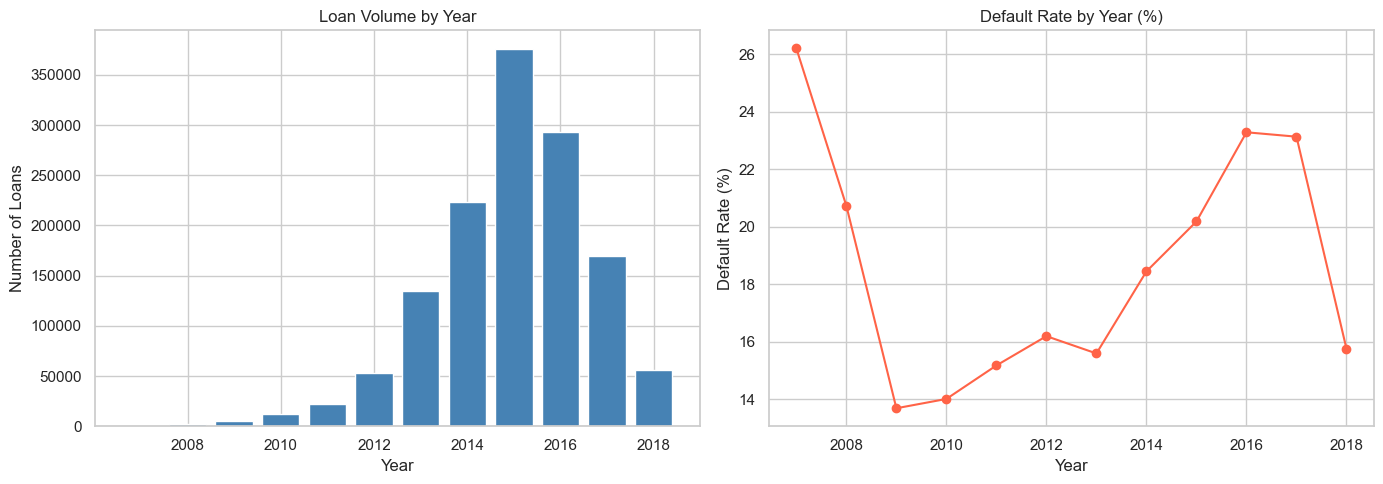

Insight: [Write your insight here — what does the trend tell a lending manager?]


In [3]:
yearly = df.groupby('issue_year').agg(
    loan_count=('loan_amnt', 'count'),
    default_rate=('default_flag', 'mean'),
    avg_int_rate=('int_rate', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['issue_year'], yearly['loan_count'], color='steelblue')
axes[0].set_title('Loan Volume by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Loans')

axes[1].plot(yearly['issue_year'], yearly['default_rate'] * 100, marker='o', color='tomato')
axes[1].set_title('Default Rate by Year (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.savefig('../tableau/screenshots/trend_default_rate_by_year.png', dpi=150)
plt.show()
print('Insight: [Write your insight here — what does the trend tell a lending manager?]')

## 3. Default Rate by Loan Grade

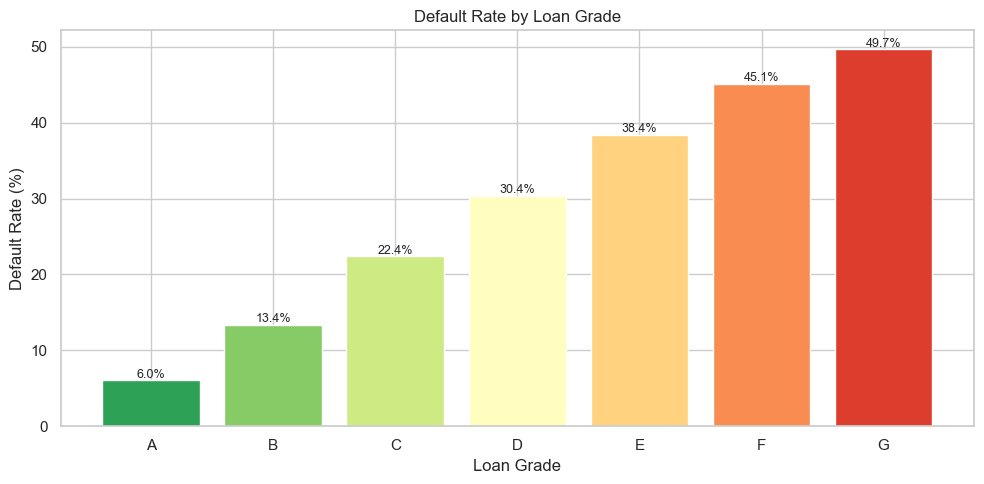

Insight: [Write your insight here — which grades carry disproportionate risk?]


In [4]:
grade_dr = df.groupby('grade')['default_flag'].mean().reset_index()
grade_dr.columns = ['grade', 'default_rate']
grade_dr = grade_dr.sort_values('grade')

plt.figure(figsize=(10, 5))
bars = plt.bar(grade_dr['grade'], grade_dr['default_rate'] * 100,
               color=sns.color_palette('RdYlGn_r', len(grade_dr)))
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
for bar, val in zip(bars, grade_dr['default_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../tableau/screenshots/default_rate_by_grade.png', dpi=150)
plt.show()
print('Insight: [Write your insight here — which grades carry disproportionate risk?]')

## 4. Default Rate by Loan Purpose

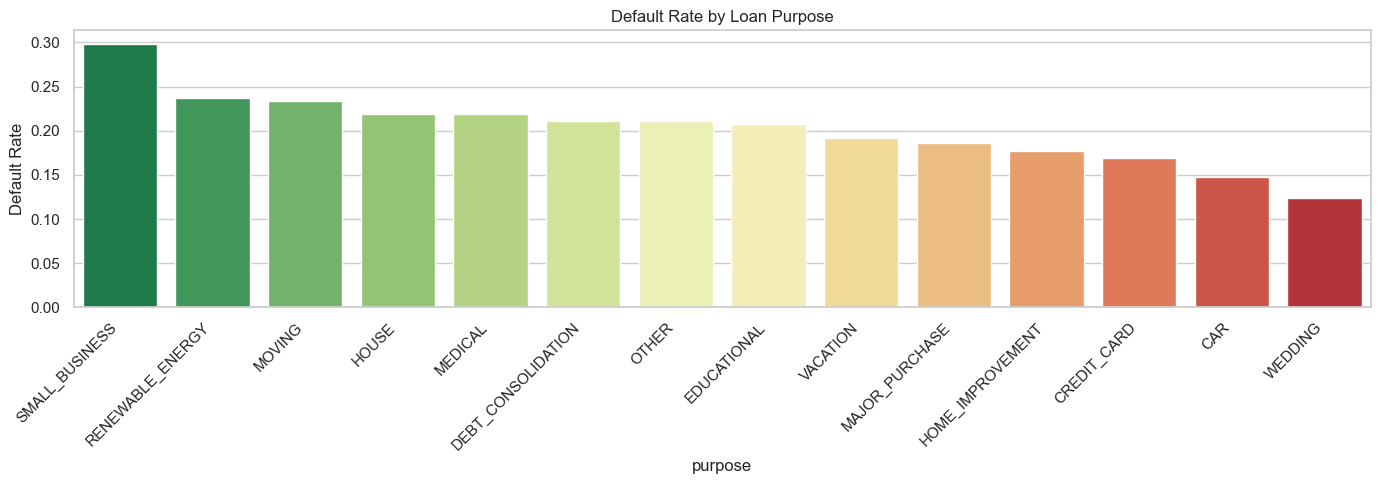

Insight: [Write your insight here]


In [5]:
purpose_dr = df.groupby('purpose').agg(
    default_rate=('default_flag', 'mean'),
    count=('default_flag', 'count')
).reset_index().sort_values('default_rate', ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(data=purpose_dr, x='purpose', y='default_rate', palette='RdYlGn_r')
plt.title('Default Rate by Loan Purpose')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('../tableau/screenshots/default_rate_by_purpose.png', dpi=150)
plt.show()
print('Insight: [Write your insight here]')

## 5. Distribution Analysis — Loan Amount, DTI, FICO

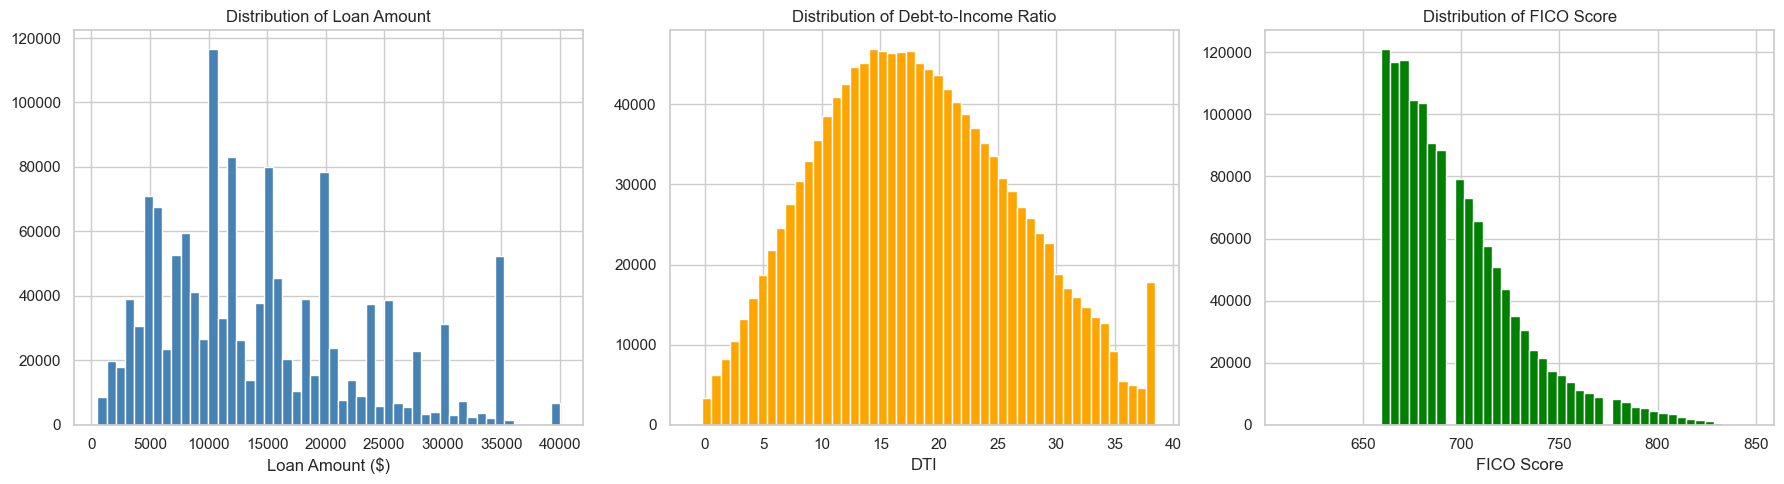

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['loan_amnt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Loan Amount')
axes[0].set_xlabel('Loan Amount ($)')

axes[1].hist(df['dti'].dropna(), bins=50, color='orange', edgecolor='white')
axes[1].set_title('Distribution of Debt-to-Income Ratio')
axes[1].set_xlabel('DTI')

axes[2].hist(df['fico_avg'].dropna(), bins=50, color='green', edgecolor='white')
axes[2].set_title('Distribution of FICO Score')
axes[2].set_xlabel('FICO Score')

plt.tight_layout()
plt.savefig('../tableau/screenshots/distributions.png', dpi=150)
plt.show()

## 6. Default Rate by Income Band and DTI Band

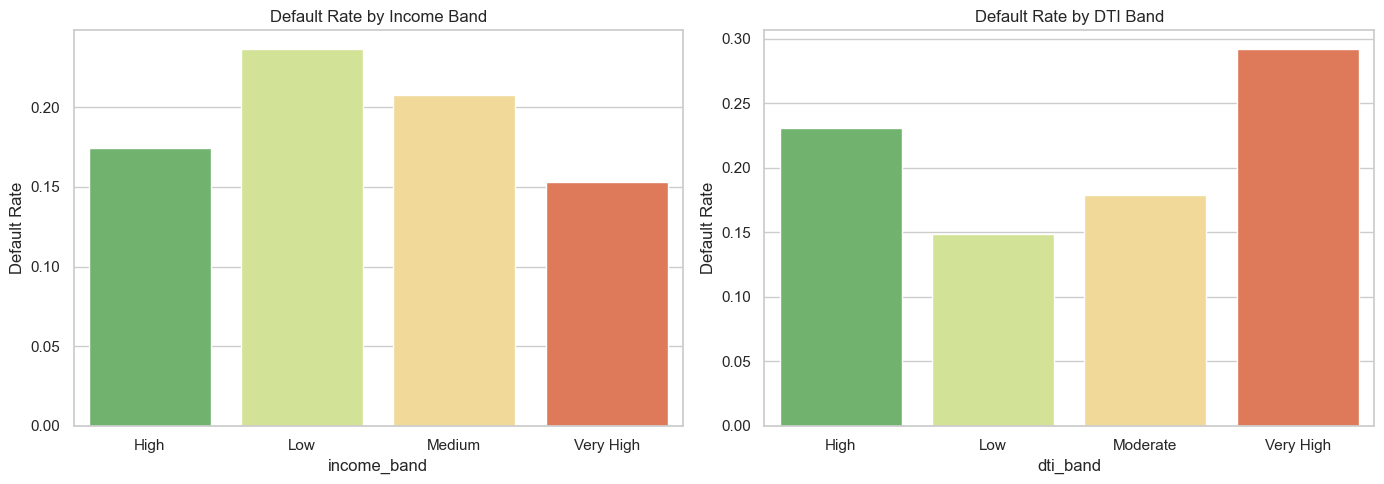

Insight: [Write your insight here]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

income_dr = df.groupby('income_band', observed=True)['default_flag'].mean().reset_index()
sns.barplot(data=income_dr, x='income_band', y='default_flag', palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Default Rate by Income Band')
axes[0].set_ylabel('Default Rate')

dti_dr = df.groupby('dti_band', observed=True)['default_flag'].mean().reset_index()
sns.barplot(data=dti_dr, x='dti_band', y='default_flag', palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Default Rate by DTI Band')
axes[1].set_ylabel('Default Rate')

plt.tight_layout()
plt.savefig('../tableau/screenshots/default_by_income_dti.png', dpi=150)
plt.show()
print('Insight: [Write your insight here]')

## 7. Correlation Analysis

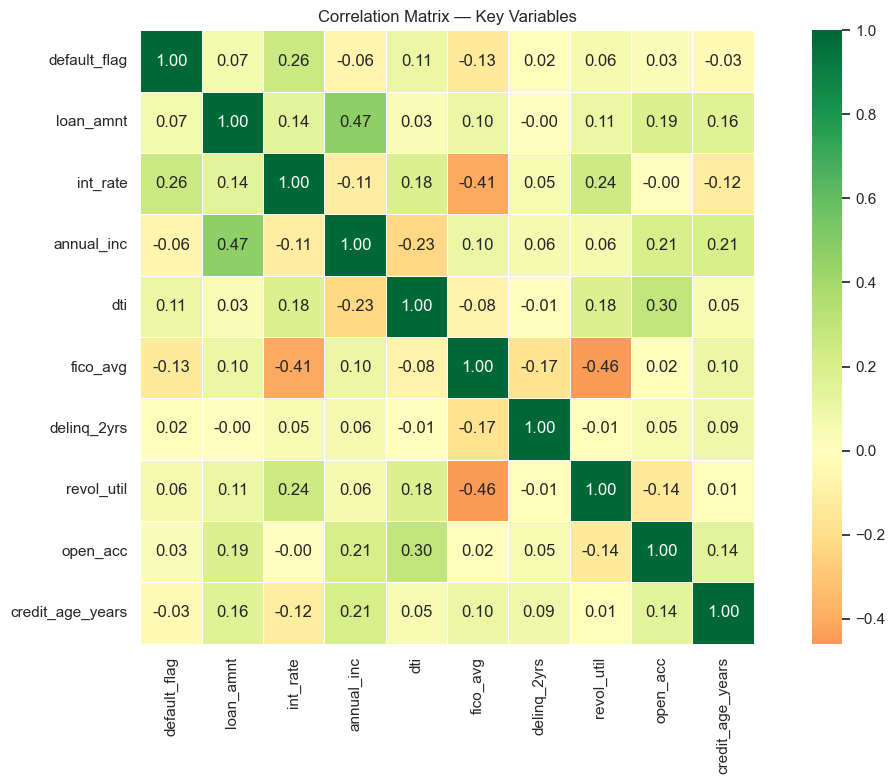


Correlation with default_flag:
default_flag        1.000000
int_rate            0.258577
dti                 0.107988
loan_amnt           0.065289
revol_util          0.059972
open_acc            0.027875
delinq_2yrs         0.019261
credit_age_years   -0.033536
annual_inc         -0.063045
fico_avg           -0.130700
Name: default_flag, dtype: float64


In [8]:
corr_cols = ['default_flag', 'loan_amnt', 'int_rate', 'annual_inc', 'dti',
             'fico_avg', 'delinq_2yrs', 'revol_util', 'open_acc', 'credit_age_years']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Variables')
plt.tight_layout()
plt.savefig('../tableau/screenshots/correlation_matrix.png', dpi=150)
plt.show()

print('\nCorrelation with default_flag:')
print(corr_matrix['default_flag'].sort_values(ascending=False))

## 8. Default Rate by State (Top 15)

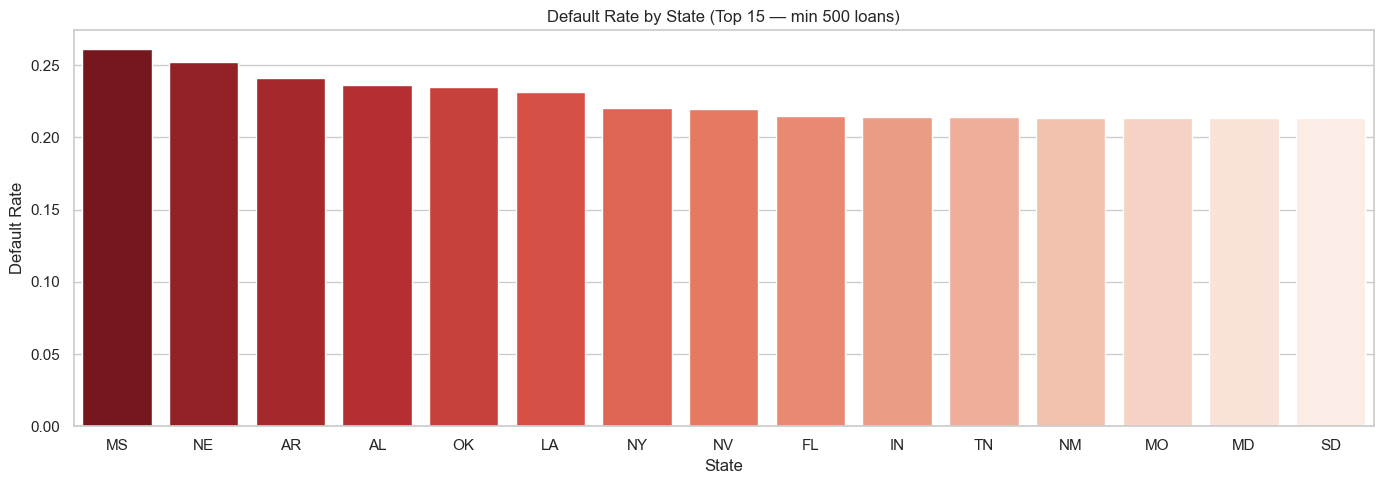

Insight: [Write your insight here]


In [9]:
state_dr = df.groupby('addr_state').agg(
    default_rate=('default_flag', 'mean'),
    count=('default_flag', 'count')
).reset_index()
state_dr = state_dr[state_dr['count'] > 500].sort_values('default_rate', ascending=False).head(15)

plt.figure(figsize=(14, 5))
sns.barplot(data=state_dr, x='addr_state', y='default_rate', palette='Reds_r')
plt.title('Default Rate by State (Top 15 — min 500 loans)')
plt.xlabel('State')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('../tableau/screenshots/default_rate_by_state.png', dpi=150)
plt.show()
print('Insight: [Write your insight here]')